# Machine Learning Models - Training & Testing (Dynamic Dataset Control)
## Network Intrusion Detection System

### Features:
- **Per-model dataset size control** - Set different sample sizes for each model
- **Model-specific directories** - Each model saves to its own subdirectory
- **Optimized for slow models** - Use smaller datasets for KNN and SVM

### Models:
1. Random Forest (RF)
2. Decision Tree (DT)
3. XGBoost
4. K-Nearest Neighbors (KNN)
5. Support Vector Machine (SVM)
6. Naive Bayes (NB)

In [ ]:
import pandas as pd
import numpy as np
import time
import pickle
import warnings
warnings.filterwarnings('ignore')
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             balanced_accuracy_score)

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# ========================================
# CONFIGURATION
# ========================================

INPUT_FILE = "archive/full_df_binary_labels.csv"
BASE_MODEL_DIR = "trained_models/ml/"
TEST_SIZE = 0.2
RANDOM_STATE = 42
SAVE_MODELS = True

# ========================================
# PER-MODEL DATASET SIZE CONTROL
# ========================================
# Set the number of rows to use for each model
# None = use full dataset
# Integer = use that many rows (will be sampled from full dataset)

MODEL_SAMPLE_SIZES = {
    'Random Forest': None,        # Fast - use full dataset
    'Decision Tree': None,        # Fast - use full dataset
    'XGBoost': None,              # Fast - use full dataset
    'KNN': 50000,                 # SLOW - use only 50k rows
    'SVM': 100000,                # VERY SLOW - use only 100k rows
    'Naive Bayes': None           # Fast - use full dataset
}

print("📊 Per-Model Sample Sizes:")
for model, size in MODEL_SAMPLE_SIZES.items():
    size_str = 'Full dataset' if size is None else f'{size:,} rows'
    print(f"   {model}: {size_str}")

# Create base directory
os.makedirs(BASE_MODEL_DIR, exist_ok=True)
print(f"\n✅ Base model directory: {BASE_MODEL_DIR}")

📊 Per-Model Sample Sizes:
   Random Forest: Full dataset
   Decision Tree: Full dataset
   XGBoost: Full dataset
   KNN: 50,000 rows
   SVM: 100,000 rows
   Naive Bayes: Full dataset

✅ Base model directory: trained_models/ml/


In [3]:
# ========================================
# LOAD DATASET (Memory-Efficient)
# ========================================

CHUNK_SIZE = 100000
MAX_ROWS = None  # None = load all data, or set a limit

# Initialize lists to store chunks
chunks = []
total_rows = 0

# Read in chunks
print("⏳ Reading data...")
for i, chunk in enumerate(pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)):
    # Check if we've reached max rows
    if MAX_ROWS and total_rows >= MAX_ROWS:
        break
    
    # If this chunk would exceed MAX_ROWS, truncate it
    if MAX_ROWS and total_rows + len(chunk) > MAX_ROWS:
        chunk = chunk.head(MAX_ROWS - total_rows)
    
    chunks.append(chunk)
    total_rows += len(chunk)
    
    # Progress update every 5 chunks
    if (i + 1) % 5 == 0:
        print(f"   Loaded chunk {i+1}: {total_rows:,} rows total")

print(f"\n✅ Loaded {len(chunks)} chunks")
print(f"✅ Total rows: {total_rows:,}")

# Combine chunks
print("\n🔗 Combining chunks...")
df_full = pd.concat(chunks, ignore_index=True)
del chunks  # Free memory

print(f"✅ Dataset shape: {df_full.shape}")
print(f"✅ Columns: {len(df_full.columns)}")
print(f"\nFirst few columns: {list(df_full.columns)[:5]}")

⏳ Reading data...
   Loaded chunk 5: 500,000 rows total
   Loaded chunk 10: 1,000,000 rows total
   Loaded chunk 15: 1,500,000 rows total
   Loaded chunk 20: 2,000,000 rows total
   Loaded chunk 25: 2,500,000 rows total
   Loaded chunk 30: 3,000,000 rows total
   Loaded chunk 35: 3,500,000 rows total
   Loaded chunk 40: 4,000,000 rows total
   Loaded chunk 45: 4,500,000 rows total
   Loaded chunk 50: 5,000,000 rows total
   Loaded chunk 55: 5,500,000 rows total
   Loaded chunk 60: 6,000,000 rows total
   Loaded chunk 65: 6,500,000 rows total
   Loaded chunk 70: 7,000,000 rows total
   Loaded chunk 75: 7,500,000 rows total
   Loaded chunk 80: 8,000,000 rows total
   Loaded chunk 85: 8,500,000 rows total
   Loaded chunk 90: 9,000,000 rows total
   Loaded chunk 95: 9,500,000 rows total
   Loaded chunk 100: 10,000,000 rows total
   Loaded chunk 105: 10,500,000 rows total
   Loaded chunk 110: 11,000,000 rows total
   Loaded chunk 115: 11,500,000 rows total
   Loaded chunk 120: 12,000,000 ro

In [14]:
# Display first few rows
print("📊 First 5 rows:")
display(df_full.head(20))

# Memory usage
print(f"\n💾 Memory usage: {df_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Data info
print("\n📋 Dataset Info:")
print(f"   Shape: {df_full.shape}")
print(f"   Columns: {len(df_full.columns)}")
print(f"   Data types: {df_full.dtypes.value_counts().to_dict()}")

📊 First 5 rows:


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Idle Mean,Idle Max,Idle Min,Label_Binary
0,0,0,112641719,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320859.5,56320958.0,56320761.0,0
1,0,0,112641466,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320733.0,56320814.0,56320652.0,0
2,0,0,112638623,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56319311.5,56319525.0,56319098.0,0
3,22,6,6453966,15,10,1239.0,2273.0,744.0,82.600000,196.741237,...,10,2273,65535,233,6,32,0.0,0.0,0.0,0
4,22,6,8804066,14,11,1143.0,2209.0,744.0,81.642857,203.745545,...,11,2209,5808,233,6,32,0.0,0.0,0.0,0
5,22,6,6989341,16,12,1239.0,2273.0,744.0,77.437500,190.831154,...,12,2273,5808,234,7,20,0.0,0.0,0.0,0
6,0,0,112640480,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320240.0,56320384.0,56320096.0,0
7,0,0,112641244,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320622.0,56320666.0,56320578.0,0
8,80,6,476513,5,3,211.0,463.0,211.0,42.200000,94.362069,...,3,463,14600,219,1,32,0.0,0.0,0.0,0
9,80,6,475048,5,3,220.0,472.0,220.0,44.000000,98.386991,...,3,472,14600,219,1,32,0.0,0.0,0.0,0



💾 Memory usage: 7183.16 MB

📋 Dataset Info:
   Shape: (16232943, 58)
   Columns: 58
   Data types: {dtype('float64'): 37, dtype('int64'): 21}


📊 Class Distribution:
Label_Binary
0    13484708
1     2748235
Name: count, dtype: int64


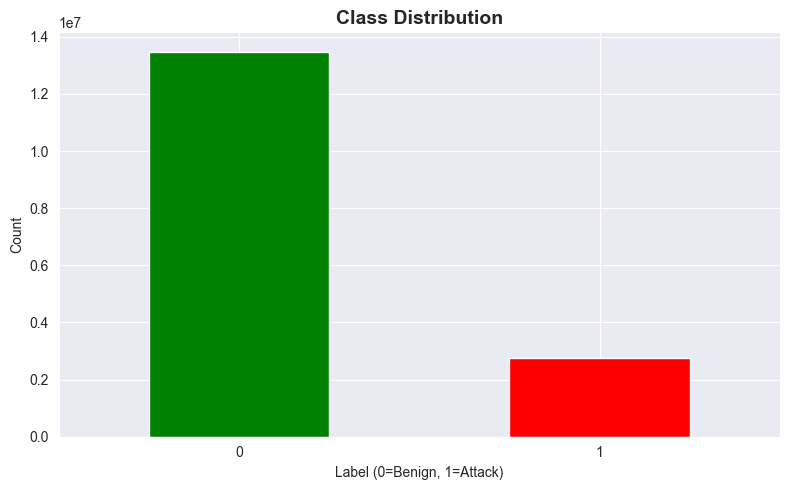


  Benign (0): 13,484,708 (83.07%)
  Attack (1): 2,748,235 (16.93%)


In [4]:
# Class distribution
print("📊 Class Distribution:")
class_counts = df_full['Label_Binary'].value_counts()
print(class_counts)

# Visualize
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Label (0=Benign, 1=Attack)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Percentages
benign_count = (df_full['Label_Binary'] == 0).sum()
attack_count = (df_full['Label_Binary'] == 1).sum()
benign_pct = benign_count / len(df_full) * 100
attack_pct = attack_count / len(df_full) * 100

print(f"\n  Benign (0): {benign_count:,} ({benign_pct:.2f}%)")
print(f"  Attack (1): {attack_count:,} ({attack_pct:.2f}%)")

In [22]:
df_full.head()

,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Mean,Fwd Pkt Len Std,...,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Idle Mean,Idle Max,Idle Min,Label_Binary
0,0,0,112641719,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320859.5,56320958.0,56320761.0,0
1,0,0,112641466,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56320733.0,56320814.0,56320652.0,0
2,0,0,112638623,3,0,0.0,0.0,0.0,0.000000,0.000000,...,0,0,-1,-1,0,0,56319311.5,56319525.0,56319098.0,0
3,22,6,6453966,15,10,1239.0,2273.0,744.0,82.600000,196.741237,...,10,2273,65535,233,6,32,0.0,0.0,0.0,0
4,22,6,8804066,14,11,1143.0,2209.0,744.0,81.642857,203.745545,...,11,2209,5808,233,6,32,0.0,0.0,0.0,0


In [5]:
# ========================================
# PREPARE FULL DATASET
# ========================================

print("🔧 Preparing data...")

# Separate features and labels

X_full = df_full.drop(['Label_Binary'], axis=1)
y_full = df_full['Label_Binary']

# Keep only numeric columns
print("\n🔢 Selecting numeric features...")
X_full = X_full.select_dtypes(include=[np.number])

print(f"\n✅ Features shape: {X_full.shape}")
print(f"✅ Labels shape: {y_full.shape}")
print(f"\nNumber of features: {X_full.shape[1]}")

# Free memory
del df_full
print("\n🧹 Freed original dataframe memory")

🔧 Preparing data...

🔢 Selecting numeric features...

✅ Features shape: (16232943, 57)
✅ Labels shape: (16232943,)

Number of features: 57

🧹 Freed original dataframe memory


In [6]:
# ========================================
# MODEL CONFIGURATIONS
# ========================================

models = {
    'Random Forest': {
        'model': RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            min_samples_split=10,
            min_samples_leaf=4,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=1
        ),
        'use_scaled': False
    },
    'Decision Tree': {
        'model': DecisionTreeClassifier(
            max_depth=20,
            min_samples_split=10,
            min_samples_leaf=4,
            random_state=RANDOM_STATE
        ),
        'use_scaled': False
    },
    'XGBoost': {
        'model': XGBClassifier(
            n_estimators=100,
            max_depth=10,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric='logloss'
        ),
        'use_scaled': False
    },
    'KNN': {
        'model': KNeighborsClassifier(
            n_neighbors=5,
            n_jobs=-1
        ),
        'use_scaled': True
    },
    'SVM': {
        'model': SVC(
            kernel='rbf',
            C=1.0,
            gamma='scale',
            random_state=RANDOM_STATE,
            verbose=True
        ),
        'use_scaled': True
    },
    'Naive Bayes': {
        'model': GaussianNB(),
        'use_scaled': False
    }
}

print(f"✅ Defined {len(models)} models:")
for model_name in models.keys():
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
    size_str = 'Full dataset' if sample_size is None else f'{sample_size:,} rows'
    print(f"   - {model_name} ({size_str})")

✅ Defined 6 models:
   - Random Forest (Full dataset)
   - Decision Tree (Full dataset)
   - XGBoost (Full dataset)
   - KNN (50,000 rows)
   - SVM (100,000 rows)
   - Naive Bayes (Full dataset)


In [16]:
# ========================================
# HELPER FUNCTION: SAMPLE DATA FOR MODEL
# ========================================

def get_model_data(X_full, y_full, model_name, sample_size, test_size, random_state):
    """
    Get train/test split for a specific model with optional sampling.
    
    Parameters:
    -----------
    X_full : DataFrame
        Full feature dataset
    y_full : Series
        Full target dataset
    model_name : str
        Name of the model (for logging)
    sample_size : int or None
        Number of rows to sample (None = use full dataset)
    test_size : float
        Proportion of test set
    random_state : int
        Random state for reproducibility
    
    Returns:
    --------
    X_train, X_test, y_train, y_test : arrays
        Train and test splits
    """
    
    if sample_size is None:
        # Use full dataset
        X = X_full
        y = y_full
        print(f"📊 Using FULL dataset: {len(X):,} rows")
    else:
        # Sample dataset
        if sample_size > len(X_full):
            print(f"⚠️  Requested {sample_size:,} rows but only {len(X_full):,} available")
            print(f"📊 Using full dataset instead")
            X = X_full
            y = y_full
        else:
            print(f"📊 Sampling {sample_size:,} rows from {len(X_full):,} total (stratified)")
            # Stratified sampling to maintain class distribution
            X, _, y, _ = train_test_split(
                X_full, y_full, 
                train_size=sample_size,
                random_state=random_state,
                stratify=y_full
            )
    
    # Train-test split
    print(f"🔪 Splitting into train/test ({test_size*100}% test)...")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    print(f"✅ Train set: {X_train.shape[0]:,} samples")
    print(f"✅ Test set: {X_test.shape[0]:,} samples")
    
    return X_train, X_test, y_train, y_test

In [ ]:
# ========================================
# TRAIN AND TEST ALL MODELS
# ========================================

results = {}
trained_models = {}

for model_name, model_config in models.items():
    print("\n" + "="*80)
    print(f"🚀 TRAINING: {model_name}")
    print("="*80)
    
    # Create model-specific directory
    model_dir = os.path.join(BASE_MODEL_DIR, model_name.lower().replace(' ', '_'), '')
    os.makedirs(model_dir, exist_ok=True)
    print(f"📁 Model directory: {model_dir}")
    
    # Get sample size for this model
    sample_size = MODEL_SAMPLE_SIZES.get(model_name)
    
    # Get train/test data with optional sampling
    X_train, X_test, y_train, y_test = get_model_data(
        X_full, y_full, 
        model_name, 
        sample_size, 
        TEST_SIZE, 
        RANDOM_STATE
    )
    
    # Feature scaling if needed
    model = model_config['model']
    use_scaled = model_config['use_scaled']
    
    if use_scaled:
        print(f"\n⚖️  Scaling features...")
        scaler = StandardScaler()
        X_train_use = scaler.fit_transform(X_train)
        X_test_use = scaler.transform(X_test)
        
        # Save scaler
        if SAVE_MODELS:
            scaler_path = os.path.join(model_dir, 'scaler.pkl')
            with open(scaler_path, 'wb') as f:
                pickle.dump(scaler, f)
            print(f"✅ Scaler saved: {scaler_path}")
        
        print(f"📊 Using: SCALED features")
    else:
        X_train_use = X_train
        X_test_use = X_test
        print(f"📊 Using: ORIGINAL features")
    
    # Training
    print(f"\n⏱️  Training...")
    start_time = time.time()
    model.fit(X_train_use, y_train)
    train_time = time.time() - start_time
    print(f"✅ Training completed in {train_time:.2f} seconds ({train_time/60:.2f} minutes)")
    
    # Prediction
    print(f"\n🔮 Making predictions...")
    start_time = time.time()
    y_pred = model.predict(X_test_use)
    pred_time = time.time() - start_time
    print(f"✅ Predictions completed in {pred_time:.2f} seconds")
    
    # Evaluation
    accuracy  = accuracy_score(y_test, y_pred)
    f1_mac    = f1_score(y_test, y_pred, average='macro', zero_division=0)
    bal_acc   = balanced_accuracy_score(y_test, y_pred)
    cm        = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    benign_recall    = tn / (tn + fp) if (tn + fp) > 0 else 0
    attack_recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    benign_precision = tn / (tn + fn) if (tn + fn) > 0 else 0
    attack_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    # Store results
    # REPLACE WITH THIS:
    results[model_name] = {
    'accuracy': accuracy,
    'balanced_accuracy': bal_acc,
    'f1_macro': f1_mac,
    'benign_recall': benign_recall,
    'attack_recall': attack_recall,
    'benign_precision': benign_precision,
    'attack_precision': attack_precision,
    'confusion_matrix': cm,
    'train_time': train_time, 'pred_time': pred_time,
    'sample_size': len(X_train) + len(X_test),
    'train_samples': len(X_train), 'test_samples': len(X_test)
                    }
    
    trained_models[model_name] = model
    
    # Print metrics
    print(f"   Balanced Accuracy : {bal_acc:.4f}  ⭐ Primary metric")
    print(f"   F1 Macro          : {f1_mac:.4f}")
    print(f"   Benign Recall     : {benign_recall:.4f}")
    print(f"   Attack Recall     : {attack_recall:.4f}")
    print(f"   Benign Precision  : {benign_precision:.4f}")
    print(f"   Attack Precision  : {attack_precision:.4f}")
    print(f"   Accuracy (ref)    : {accuracy:.4f}  ⚠️  misleading on imbalanced data")
    
    print(f"\n🕐 TIME:")
    print(f"   Train: {train_time:.2f}s ({train_time/60:.2f} min)")
    print(f"   Test:  {pred_time:.2f}s")
    
    print(f"\n🎯 Confusion Matrix:")
    print(cm)
    
    # Save model
    if SAVE_MODELS:
        model_path = os.path.join(model_dir, 'model.pkl')
        with open(model_path, 'wb') as f:
            pickle.dump(model, f)
        print(f"\n💾 Model saved: {model_path}")
        
        # Save metadata
        metadata = {
            'model_name': model_name,
            'sample_size': sample_size,
            'train_samples': len(X_train),
            'test_samples': len(X_test),
            'features': X_train.shape[1],
            'use_scaled': use_scaled,
            'train_time': train_time,
            'metrics': {
                'accuracy': accuracy,
                'precision': precision,
                'recall': recall,
                'f1_score': f1
            }
        }
        
        metadata_path = os.path.join(model_dir, 'metadata.pkl')
        with open(metadata_path, 'wb') as f:
            pickle.dump(metadata, f)
        print(f"💾 Metadata saved: {metadata_path}")

print("\n" + "="*80)
print("✅ ALL MODELS TRAINED & TESTED!")
print("="*80)


🚀 TRAINING: Random Forest
📁 Model directory: trained_models/ml/random_forest\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20.0% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples
📊 Using: ORIGINAL features

⏱️  Training...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:  5.7min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 18.8min finished


✅ Training completed in 1153.23 seconds (19.22 minutes)

🔮 Making predictions...


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.8s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    7.5s finished


✅ Predictions completed in 11.53 seconds

📊 RESULTS:
   Accuracy:  0.9901
   Precision: 0.9977
   Recall:    0.9436
   F1-Score:  0.9699

🕐 TIME:
   Train: 1153.23s (19.22 min)
   Test:  11.53s

🎯 Confusion Matrix:
[[2695762    1180]
 [  31025  518622]]

💾 Model saved: trained_models/ml/random_forest\model.pkl
💾 Metadata saved: trained_models/ml/random_forest\metadata.pkl

🚀 TRAINING: Decision Tree
📁 Model directory: trained_models/ml/decision_tree\
📊 Using FULL dataset: 16,232,943 rows
🔪 Splitting into train/test (20.0% test)...
✅ Train set: 12,986,354 samples
✅ Test set: 3,246,589 samples
📊 Using: ORIGINAL features

⏱️  Training...
✅ Training completed in 683.57 seconds (11.39 minutes)

🔮 Making predictions...
✅ Predictions completed in 2.68 seconds

📊 RESULTS:
   Accuracy:  0.9901
   Precision: 0.9968
   Recall:    0.9443
   F1-Score:  0.9698

🕐 TIME:
   Train: 683.57s (11.39 min)
   Test:  2.68s

🎯 Confusion Matrix:
[[2695278    1664]
 [  30634  519013]]

💾 Model saved: trained_mod

In [ ]:
# ========================================
# PERFORMANCE SUMMARY
# ========================================

# Create summary DataFrame
summary_data = []
for model_name, metrics in results.items():
    summary_data.append({
    'Model': model_name,
    'Balanced Accuracy': metrics['balanced_accuracy'],
    'F1 Macro': metrics['f1_macro'],
    'Benign Recall': metrics['benign_recall'],
    'Attack Recall': metrics['attack_recall'],
    'Benign Precision': metrics['benign_precision'],
    'Attack Precision': metrics['attack_precision'],
    'Accuracy': metrics['accuracy'],
    'Train Time (s)': metrics['train_time'],
    'Samples': metrics['sample_size']
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Balanced Accuracy', ascending=False)

print("📊 PERFORMANCE SUMMARY (sorted by F1-Score):")
print("="*100)
display(summary_df.style.background_gradient(
    subset=['Accuracy', 'Precision', 'Recall', 'F1-Score'], 
    cmap='RdYlGn'
))

# Save summary
if SAVE_MODELS:
    summary_path = os.path.join(BASE_MODEL_DIR, 'training_summary.csv')
    summary_df.to_csv(summary_path, index=False)
    print(f"\n💾 Summary saved to {summary_path}")

📊 PERFORMANCE SUMMARY (sorted by F1-Score):


,Model,Sample Size,Train Samples,Test Samples,Accuracy,Precision,Recall,F1-Score,Train Time (s),Train Time (min),Test Time (s)
0,XGBoost,16232943,12986354,3246589,0.990175,0.998563,0.943325,0.970159,82.770422,1.379507,2.093271
1,Random Forest,16232943,12986354,3246589,0.990080,0.997730,0.943555,0.969886,1153.225137,19.220419,11.533943
2,Decision Tree,16232943,12986354,3246589,0.990052,0.996804,0.944266,0.969824,683.570415,11.392840,2.683334
3,KNN,50000,40000,10000,0.988700,0.987654,0.945068,0.965892,0.013777,0.000230,3.034926
4,SVM,100000,80000,20000,0.977700,0.993620,0.873892,0.929918,27.982355,0.466373,5.900822
5,Naive Bayes,16232943,12986354,3246589,0.274833,0.185706,0.970008,0.311732,30.416145,0.506936,5.918479



💾 Summary saved to trained_models/ml/training_summary.csv


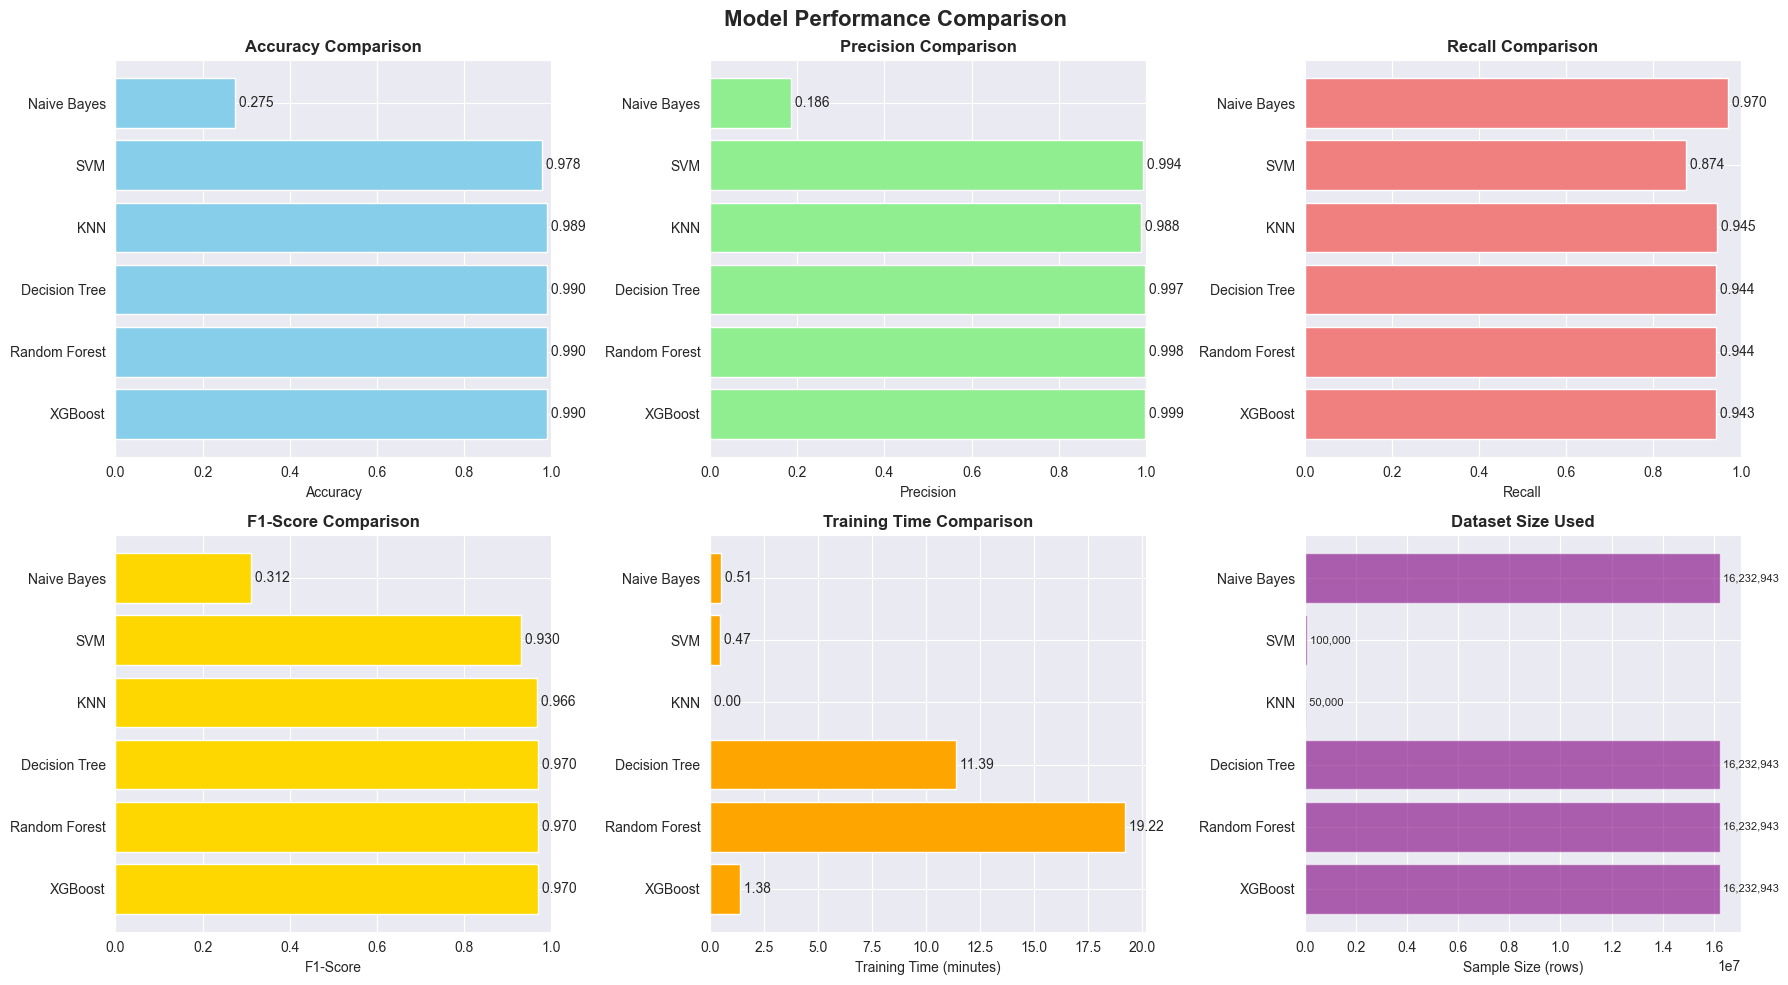


💾 Visualization saved to trained_models/ml/performance_comparison.png


In [19]:
# ========================================
# VISUALIZATION: PERFORMANCE COMPARISON
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Accuracy
axes[0, 0].barh(summary_df['Model'], summary_df['Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Accuracy Comparison', fontweight='bold')
axes[0, 0].set_xlim(0, 1)
for i, v in enumerate(summary_df['Accuracy']):
    axes[0, 0].text(v, i, f' {v:.3f}', va='center')

# Precision
axes[0, 1].barh(summary_df['Model'], summary_df['Precision'], color='lightgreen')
axes[0, 1].set_xlabel('Precision')
axes[0, 1].set_title('Precision Comparison', fontweight='bold')
axes[0, 1].set_xlim(0, 1)
for i, v in enumerate(summary_df['Precision']):
    axes[0, 1].text(v, i, f' {v:.3f}', va='center')

# Recall
axes[0, 2].barh(summary_df['Model'], summary_df['Recall'], color='lightcoral')
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_title('Recall Comparison', fontweight='bold')
axes[0, 2].set_xlim(0, 1)
for i, v in enumerate(summary_df['Recall']):
    axes[0, 2].text(v, i, f' {v:.3f}', va='center')

# F1-Score
axes[1, 0].barh(summary_df['Model'], summary_df['F1-Score'], color='gold')
axes[1, 0].set_xlabel('F1-Score')
axes[1, 0].set_title('F1-Score Comparison', fontweight='bold')
axes[1, 0].set_xlim(0, 1)
for i, v in enumerate(summary_df['F1-Score']):
    axes[1, 0].text(v, i, f' {v:.3f}', va='center')

# Training Time
axes[1, 1].barh(summary_df['Model'], summary_df['Train Time (min)'], color='orange')
axes[1, 1].set_xlabel('Training Time (minutes)')
axes[1, 1].set_title('Training Time Comparison', fontweight='bold')
for i, v in enumerate(summary_df['Train Time (min)']):
    axes[1, 1].text(v, i, f' {v:.2f}', va='center')

# Sample Size
axes[1, 2].barh(summary_df['Model'], summary_df['Sample Size'], color='purple', alpha=0.6)
axes[1, 2].set_xlabel('Sample Size (rows)')
axes[1, 2].set_title('Dataset Size Used', fontweight='bold')
for i, v in enumerate(summary_df['Sample Size']):
    axes[1, 2].text(v, i, f' {v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(f"{BASE_MODEL_DIR}performance_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Visualization saved to {BASE_MODEL_DIR}performance_comparison.png")

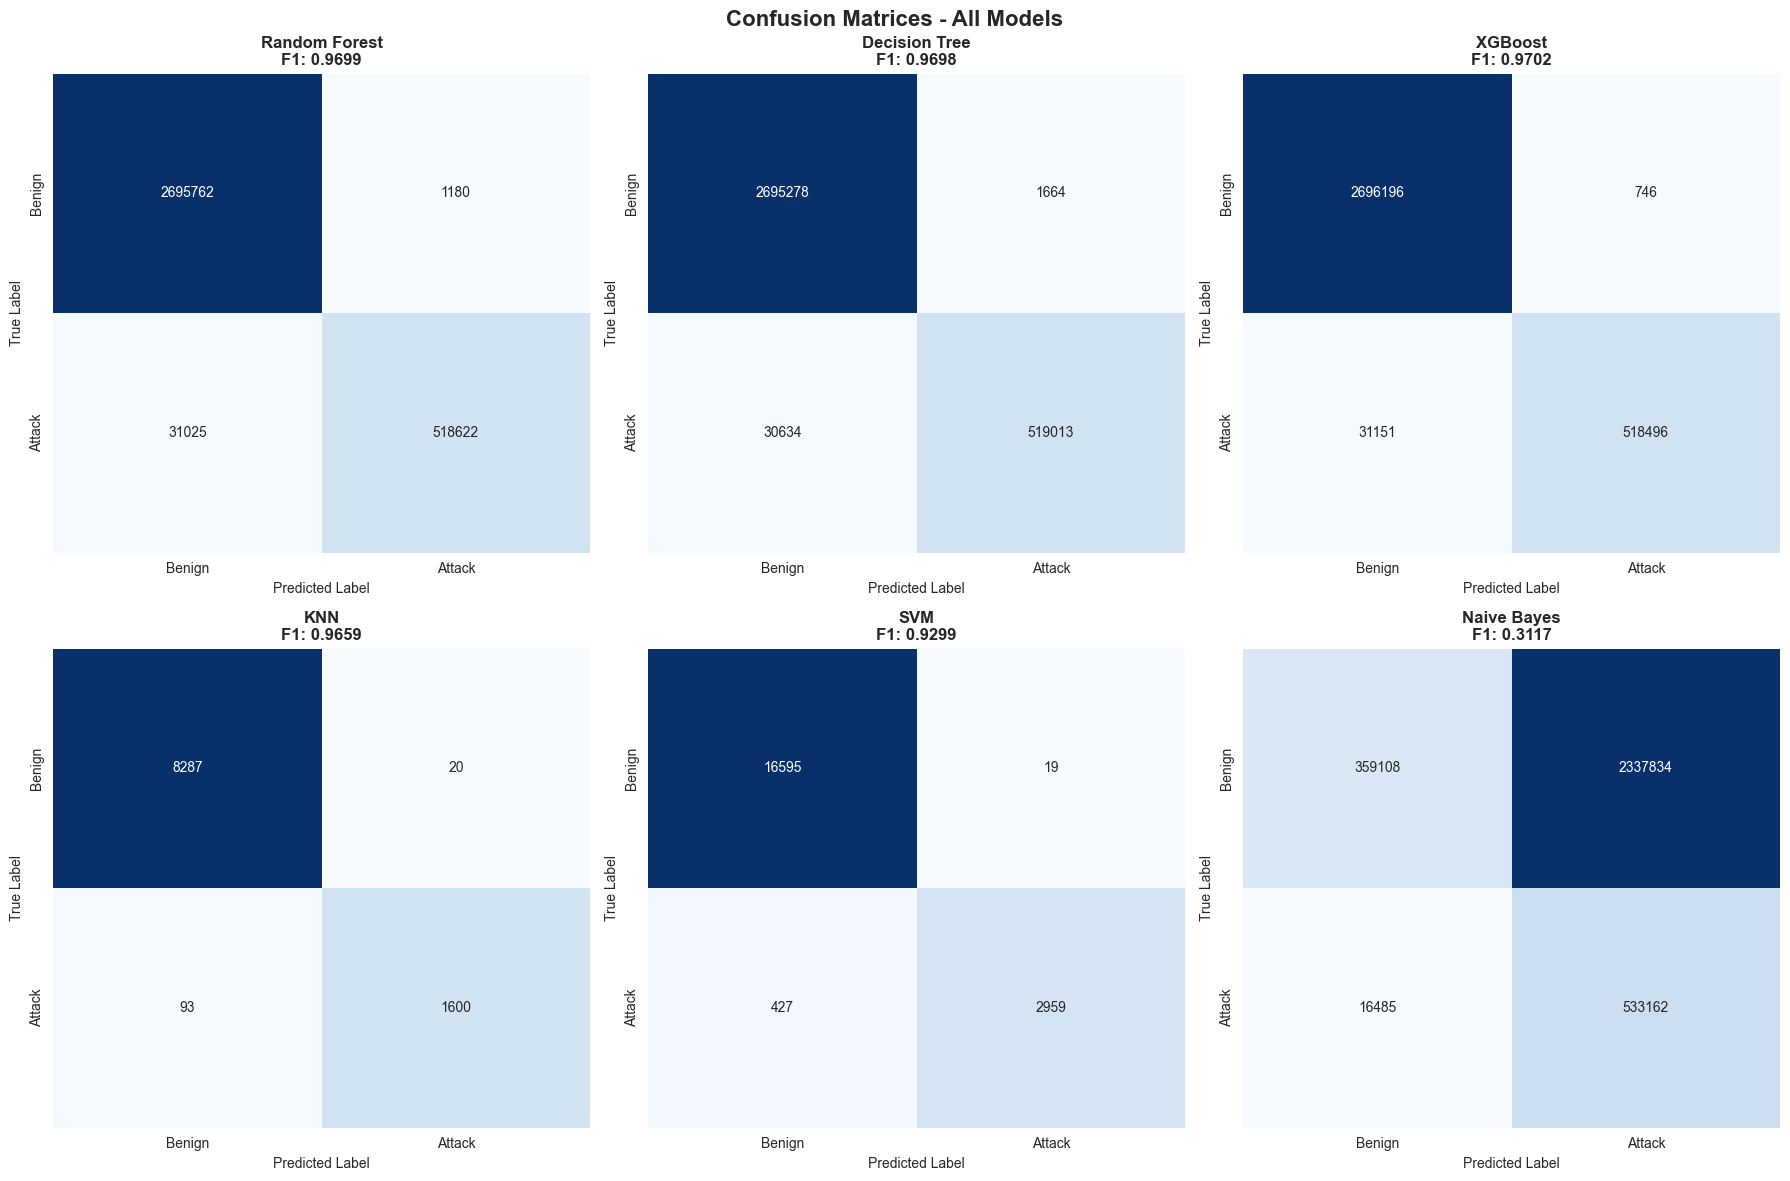


💾 Confusion matrices saved to trained_models/ml/confusion_matrices.png


In [ ]:
# ========================================
# CONFUSION MATRICES VISUALIZATION
# ========================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold')

for idx, (model_name, metrics) in enumerate(results.items()):
    row = idx // 3
    col = idx % 3
    
    cm = metrics['confusion_matrix']
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                ax=axes[row, col], cbar=False,
                xticklabels=['Benign', 'Attack'],
                yticklabels=['Benign', 'Attack'])
    
    axes[row, col].set_title(
    f'{model_name}\nBal.Acc={metrics["balanced_accuracy"]:.4f}\n'
    f'B.Rec={metrics["benign_recall"]:.4f} | A.Rec={metrics["attack_recall"]:.4f}' ,
                             fontweight='bold')
    axes[row, col].set_ylabel('True Label')
    axes[row, col].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(f"{BASE_MODEL_DIR}confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"\n💾 Confusion matrices saved to {BASE_MODEL_DIR}confusion_matrices.png")

In [21]:
# ========================================
# FINAL SUMMARY
# ========================================

print("\n" + "="*80)
print("🎉 TRAINING COMPLETE!")
print("="*80)

print("\n📊 Models Ranked by F1-Score:")
for idx, row in summary_df.iterrows():
    print(f"   {idx+1}. {row['Model']}: {row['F1-Score']:.4f} "
          f"(trained on {row['Sample Size']:,} samples)")

print(f"\n📁 All models saved to: {BASE_MODEL_DIR}")
print("\n📁 Directory structure:")
for model_name in models.keys():
    model_dir = model_name.lower().replace(' ', '_')
    print(f"   {BASE_MODEL_DIR}{model_dir}/")
    print(f"      ├── model.pkl")
    print(f"      ├── metadata.pkl")
    if models[model_name]['use_scaled']:
        print(f"      └── scaler.pkl")

print("\n" + "="*80)


🎉 TRAINING COMPLETE!

📊 Models Ranked by F1-Score:
   1. XGBoost: 0.9702 (trained on 16,232,943 samples)
   2. Random Forest: 0.9699 (trained on 16,232,943 samples)
   3. Decision Tree: 0.9698 (trained on 16,232,943 samples)
   4. KNN: 0.9659 (trained on 50,000 samples)
   5. SVM: 0.9299 (trained on 100,000 samples)
   6. Naive Bayes: 0.3117 (trained on 16,232,943 samples)

📁 All models saved to: trained_models/ml/

📁 Directory structure:
   trained_models/ml/random_forest/
      ├── model.pkl
      ├── metadata.pkl
   trained_models/ml/decision_tree/
      ├── model.pkl
      ├── metadata.pkl
   trained_models/ml/xgboost/
      ├── model.pkl
      ├── metadata.pkl
   trained_models/ml/knn/
      ├── model.pkl
      ├── metadata.pkl
      └── scaler.pkl
   trained_models/ml/svm/
      ├── model.pkl
      ├── metadata.pkl
      └── scaler.pkl
   trained_models/ml/naive_bayes/
      ├── model.pkl
      ├── metadata.pkl

